# Level 2 Task 1- Restaurant Ratings
#### Objective
Analyze the distribution of aggregate ratings, find the most 
common rating range, and calculate the average number of votes.

Step 1 → Look at the ratings column

Step 2 → Find the distribution of ratings

Step 3 → Find the most common rating range

Step 4 → Calculate average votes

Step 5 → Make a chart to show rating distribution

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Restaurant Analysis.xlsx')
df.columns = df.columns.str.replace('ï»¿', '')

### Distribution of Aggregate Ratings

In [12]:
# Quick summary of rating column - min, max, mean and distribution
print(df['Aggregate rating'].describe())

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


Instead of writing 8 separate lines of code to find min, max, average etc. — describe() gives everything in one line.

#### Observation

All 9,551 restaurants have a rating.
The average rating across all restaurants is 2.67 out of 5.
Ratings range from a minimum of 0.0 to a maximum of 4.9.
25% of restaurants are rated 2.5 or below and 75% are rated 
3.7 or below. The minimum value of 0 likely indicates that 
some restaurants have not been rated yet.

### Finding Most Common Rating Range

We divide ratings into groups of 1 point each and count 
how many restaurants fall in each group.

In [5]:
bins = [0, 1, 2, 3, 4, 5]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

# Create rating groups and assign each restaurant to a group
df['rating_range'] = pd.cut(df['Aggregate rating'], bins=bins, 
                             labels=labels, include_lowest=True)

# Count restaurants in each group and display in order
print(df['rating_range'].value_counts().sort_index())

rating_range
0-1    2148
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64


In [6]:
most_common = df['rating_range'].value_counts().idxmax()
print("Most common rating range:", most_common)

Most common rating range: 3-4


#### Observation

The most common rating range is 3-4 with 4,388 restaurants. 
The 0-1 range has 2,148 restaurants which likely represents 
unrated restaurants rather than poorly rated ones. 
Very few restaurants (only 10) fall in the 1-2 range.

### Visualizing Rating Distribution

A bar chart showing how many restaurants fall in each rating range.

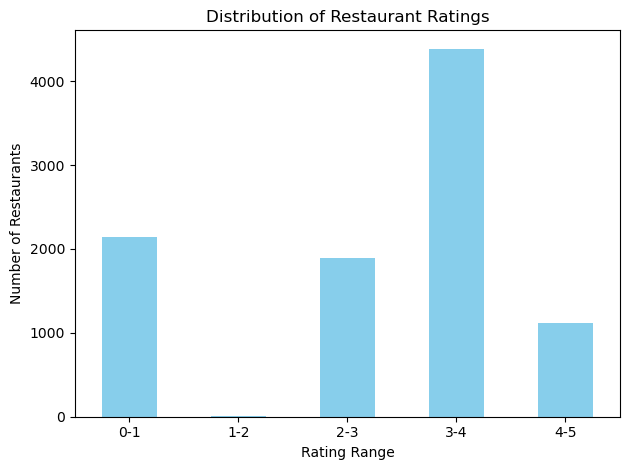

In [13]:
rating_counts = df['rating_range'].value_counts().sort_index()

rating_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating Range')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Observation

The 3-4 rating range has the most restaurants with 4,388.
The 0-1 range shows 2,148 restaurants but most of them 
are unrated with a default value of 0.
The 1-2 range has only 10 restaurants which is too small 
to see clearly in the chart.

### Calculating Average Number of Votes

We calculate the average number of votes received 
by restaurants across the entire dataset.

In [8]:
avg_votes = df['Votes'].mean()
print("Average number of votes:", round(avg_votes, 2))

Average number of votes: 156.91


#### Observation

The average number of votes received by a restaurant is 156.91. 
This means on average each restaurant has been reviewed or 
voted by around 157 customers.